In [2]:
import os
nthreads = 1
os.environ["OMP_NUM_THREADS"] = str(nthreads)
os.environ["OPENBLAS_NUM_THREADS"] = str(nthreads)
os.environ["MKL_NUM_THREADS"] = str(nthreads)

In [3]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import inferagni as ia
import pandas as pd
from cmcrameri import cm
from copy import deepcopy

/home/harrison/miniforge3/envs/proteus/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/harrison/.var/app/com.visualstudio.code/config', but the default location, /home/harrison/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [4]:
%config InlineBackend.figure_format = 'retina'

In [6]:
cases = {"wo_inst":None, "wi_inst":None}

outdir = "output/"

for k in cases.keys():
    outdir_planet = f"{outdir}/pi_Men_c-{k}/"
    print(outdir_planet)

    samps = pd.read_csv(outdir_planet+"result.csv",skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(outdir_planet+"truth.csv" ,skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # get last samples from samps
    end_frac = 0.01
    nsamp = int(len(samps)*(1-end_frac))
    samps = samps.iloc[-nsamp:]

    cases[k] = {"samps":samps, "truth":truth}

    print(truth.keys())
    print(samps.keys())

output//pi_Men_c-wo_inst/


FileNotFoundError: [Errno 2] No such file or directory: 'output//pi_Men_c-wo_inst/result.csv'

TypeError: 'NoneType' object is not subscriptable

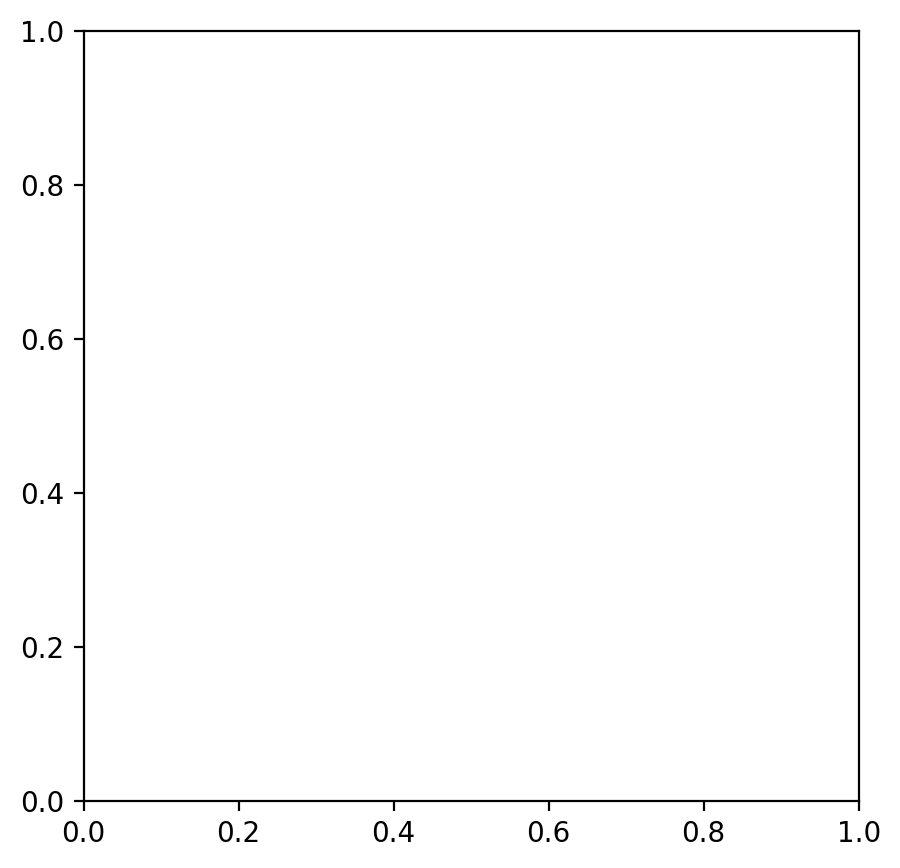

In [ ]:
fig,ax = plt.subplots(1,1, figsize=(5,5))

xkey = "frac_atm"
ykey = "logZ"

for k in cases.keys():
    x = cases[k]["samps"][xkey]
    y = cases[k]["samps"][ykey]
    ax.hist2d(x,y, label=k)

fig.savefig()
plt.show()